
# Beer 실험 v2: Train PCA(231 축 생성 → 0분산 축 제거) + 단일 PC(1D) 선형회귀로 관능(50개) 예측 랭킹
요청한 수정사항을 반영했습니다.

## 저장 구조 (요청사항 반영)
- **RUN_DIR(고정)**: `/home/a202192020/맥주데이터실험/pca/0223/pca_y1/output/20260223_174342`
- RUN_DIR 아래에
  - `종합/` : PCA 축, EVR 텍스트/그래프, 재구성 성능, 전체 결과 종합 저장
  - `target_01_<target명>/` ... `target_50_<target명>/` : 각 관능평가(1개)에 대한 결과를 해당 폴더에 전부 저장

## PCA 처리 (요청사항 반영)
- Train(175)으로 PCA 수행 → **231개 직교축 전체 생성**
- EVR(Explained Variance Ratio)을 **텍스트 + 그래프**로 저장
- EVR=0(또는 tol 이하) 축은 버림 → **사용할 PCA 축만 따로 저장**
- 사용 PCA 축으로 train/test를 투영했다가 원래 공간으로 복원하여 **복원력(재구성 오차)** 확인

## 회귀 실험 (요청사항 반영)
- 관능 50개를 **1개씩** 반복
- 각 target마다:
  - 남아있는 PC 축을 **1개씩만 사용(1D)**해서 train으로 선형회귀 학습
  - test에서 성능 계산 후 PC들을 성능 순으로 정렬해 저장

## “정확도” 컬럼 정의 (추가)
회귀에서 accuracy는 정의가 애매하므로,
- `train_accuracy`, `test_accuracy`는 **Pearson 상관계수(correlation)** 로 저장합니다.
  - 값 범위: [-1, 1]
  - R²와는 다른 정보(방향성 포함)를 줄 수 있음


In [1]:

import os
import re
import datetime as dt
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from IPython.display import display


In [2]:

# =========================================================
# 0) 설정 (요청 경로 반영)
# =========================================================

# ---- 데이터 경로 ----
DATA_XLSX_PATH     = r"/home/a202192020/맥주데이터실험/data/Supplemental Files and Figure source files.xlsx"
FALLBACK_XLSX_PATH = r"/mnt/data/Supplemental Files and Figure source files.xlsx"
CHEM_SHEET = "Supplementary File S1"
SENS_SHEET = "Supplementary File S4"

# ---- 출력 경로(고정) ----
RUN_DIR = r"/home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output"
SUMMARY_DIR = os.path.join(RUN_DIR, "종합")

os.makedirs(RUN_DIR, exist_ok=True)
os.makedirs(SUMMARY_DIR, exist_ok=True)

# ---- 분할 ----
TEST_SIZE = 0.30
RANDOM_STATE = 0  # 논문 재현 split과 맞추려면 0 권장
STRATIFY_COL = "tasting_category_fine"

# ---- PCA 전처리 ----
STANDARDIZE_BEFORE_PCA = True   # True: 상관(표준화된 공분산) 기준 PCA
EIG_TOL = 1e-12                 # EVR==0 판정을 위한 고유값 tol (수치 오차 고려)

# ---- 결과 설정 ----
TOP_N_PER_TARGET = 30           # target별 top N PC를 별도 저장

# ---- 파일명 (종합 폴더 내) ----
PCA_FULL_NPZ   = os.path.join(SUMMARY_DIR, "pca_axes_full_231.npz")
PCA_KEPT_NPZ   = os.path.join(SUMMARY_DIR, "pca_axes_kept_nonzero.npz")
EV_CSV_PATH    = os.path.join(SUMMARY_DIR, "explained_variance_ratio_all_pcs.csv")
EV_TXT_PATH    = os.path.join(SUMMARY_DIR, "explained_variance_ratio_all_pcs.txt")
EVR_PNG_PATH   = os.path.join(SUMMARY_DIR, "evr_per_pc.png")
CUMEVR_PNG_PATH= os.path.join(SUMMARY_DIR, "cumulative_evr.png")
RECON_CSV_PATH = os.path.join(SUMMARY_DIR, "reconstruction_check_train_test.csv")

ALLRES_CSV_PATH= os.path.join(SUMMARY_DIR, "single_pc_results_all_targets.csv")
TOPRES_CSV_PATH= os.path.join(SUMMARY_DIR, "top_pc_per_target.csv")
BEST1_CSV_PATH = os.path.join(SUMMARY_DIR, "best_pc_per_target.csv")
PC_FREQ_CSV    = os.path.join(SUMMARY_DIR, "best_pc_frequency.csv")

print("RUN_DIR:", RUN_DIR)
print("SUMMARY_DIR:", SUMMARY_DIR)


RUN_DIR: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output
SUMMARY_DIR: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합


In [3]:

# =========================================================
# 1) Excel 로드 + merge
# =========================================================
xlsx_path = DATA_XLSX_PATH
if not os.path.exists(xlsx_path):
    if os.path.exists(FALLBACK_XLSX_PATH):
        xlsx_path = FALLBACK_XLSX_PATH
        print("⚠️ using fallback:", xlsx_path)
    else:
        raise FileNotFoundError(f"Excel not found:\n- {DATA_XLSX_PATH}\n- {FALLBACK_XLSX_PATH}")

chem_df = pd.read_excel(xlsx_path, sheet_name=CHEM_SHEET)
sens_df = pd.read_excel(xlsx_path, sheet_name=SENS_SHEET)

META_COLS = ["beer", "beer_id", "tasting_category_fine"]

df = chem_df.merge(sens_df, on=META_COLS, how="inner", validate="one_to_one")
print("merged df:", df.shape)

feature_cols = [c for c in chem_df.columns if c not in META_COLS]
target_cols  = [c for c in sens_df.columns if c not in META_COLS]

print("#features:", len(feature_cols), " #targets:", len(target_cols))
assert len(feature_cols) == 231, f"features={len(feature_cols)} (expected 231)"
assert len(target_cols)  == 50,  f"targets={len(target_cols)} (expected 50)"


merged df: (250, 284)
#features: 231  #targets: 50


In [4]:

# =========================================================
# 2) Train/Test split (175/75) + style stratify
# =========================================================
train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=df[STRATIFY_COL]
)

X_train = train_df[feature_cols].copy()
X_test  = test_df[feature_cols].copy()

Y_train = train_df[target_cols].copy()
Y_test  = test_df[target_cols].copy()

print("train:", X_train.shape, Y_train.shape, "test:", X_test.shape, Y_test.shape)

# 결측치: train 평균으로 대체 (누수 방지)
impute_means = X_train.mean(axis=0)
X_train = X_train.fillna(impute_means)
X_test  = X_test.fillna(impute_means)

print("missing train:", int(X_train.isna().sum().sum()), "missing test:", int(X_test.isna().sum().sum()))

# (참고) n_train=175이면 센터링 후 rank <= 174 이므로 EVR=0인 축이 많이 생기는 것이 정상입니다.


train: (175, 231) (175, 50) test: (75, 231) (75, 50)
missing train: 0 missing test: 0


In [5]:

# =========================================================
# 3) Train PCA(공분산행렬 고유분해)로 231개 직교축 생성
#    - EVR(분산비율) 계산
#    - EVR=0(고유값<=tol) 축 제거 → kept 축 저장
# =========================================================

Xtr = X_train.values.astype(float)
Xte = X_test.values.astype(float)

# (A) 센터링/표준화 파라미터는 train에서만 추정
mu = Xtr.mean(axis=0)
Xtr_c = Xtr - mu
Xte_c = Xte - mu

if STANDARDIZE_BEFORE_PCA:
    sigma = Xtr_c.std(axis=0, ddof=0)
    sigma_safe = sigma.copy()
    sigma_safe[sigma_safe == 0] = 1.0
    Xtr_cs = Xtr_c / sigma_safe
    Xte_cs = Xte_c / sigma_safe
else:
    sigma_safe = np.ones(Xtr_c.shape[1], dtype=float)
    Xtr_cs = Xtr_c
    Xte_cs = Xte_c

n_train, p = Xtr_cs.shape
print("n_train:", n_train, "p:", p)

# (B) 공분산행렬 S = (X^T X)/(n-1)
S = (Xtr_cs.T @ Xtr_cs) / (n_train - 1)

# (C) 고유분해 (대칭행렬: eigh)
eigvals, eigvecs = np.linalg.eigh(S)     # ascending
idx = np.argsort(eigvals)[::-1]          # descending
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]               # columns are eigenvectors

# 수치오차 보정(아주 작은 음수 -> 0)
eigvals = np.clip(eigvals, 0, None)

total_var = eigvals.sum()
evr = eigvals / total_var if total_var > 0 else np.zeros_like(eigvals)

# (D) "0 분산(=0 EVR)" 축 제거
keep_mask = eigvals > EIG_TOL
k_keep = int(keep_mask.sum())
dropped = int((~keep_mask).sum())

print(f"kept components (eig > {EIG_TOL}): {k_keep}/{p}")
print(f"dropped (≈0 variance): {dropped}")

V_keep = eigvecs[:, keep_mask]      # (p, k_keep)
lam_keep = eigvals[keep_mask]
evr_keep = evr[keep_mask]

kept_full_indices = np.where(keep_mask)[0]  # 0-based indices in full PC list

# (E) 투영(PC score)
Z_train = Xtr_cs @ V_keep
Z_test  = Xte_cs @ V_keep

print("Z_train:", Z_train.shape, "Z_test:", Z_test.shape)

# (F) PCA 축 저장: full(231) + kept(nonzero)
np.savez(
    PCA_FULL_NPZ,
    feature_cols=np.array(feature_cols, dtype=object),
    mu=mu,
    sigma=sigma_safe,
    standardize_before_pca=np.array([STANDARDIZE_BEFORE_PCA]),
    eig_tol=np.array([EIG_TOL]),
    eigvals=eigvals,
    eigvecs=eigvecs,
    evr=evr,
)
np.savez(
    PCA_KEPT_NPZ,
    feature_cols=np.array(feature_cols, dtype=object),
    mu=mu,
    sigma=sigma_safe,
    standardize_before_pca=np.array([STANDARDIZE_BEFORE_PCA]),
    eig_tol=np.array([EIG_TOL]),
    keep_mask=keep_mask,
    kept_full_indices=kept_full_indices,
    V_keep=V_keep,
    lam_keep=lam_keep,
    evr_keep=evr_keep,
)
print("✅ saved:", PCA_FULL_NPZ)
print("✅ saved:", PCA_KEPT_NPZ)

# (G) EVR 테이블 저장(csv + txt)
ev_df = pd.DataFrame({
    "pc_index_1based_full": np.arange(1, p+1),
    "eigenvalue": eigvals,
    "explained_variance_ratio": evr,
    "explained_variance_ratio_percent": evr * 100.0,
    "kept_nonzero": keep_mask
})
ev_df.to_csv(EV_CSV_PATH, index=False)

# 텍스트(퍼센트 확인용)
with open(EV_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(f"STANDARDIZE_BEFORE_PCA={STANDARDIZE_BEFORE_PCA}\n")
    f.write(f"n_train={n_train}, p={p}\n")
    f.write(f"eig_tol={EIG_TOL}\n")
    f.write(f"kept={k_keep}, dropped={dropped}\n\n")
    f.write("PC_index\tEigenvalue\tEVR(%)\tKept\n")
    for i in range(p):
        f.write(f"{i+1}\t{eigvals[i]:.6e}\t{evr[i]*100:.8f}\t{bool(keep_mask[i])}\n")

print("✅ saved:", EV_CSV_PATH)
print("✅ saved:", EV_TXT_PATH)


n_train: 175 p: 231
kept components (eig > 1e-12): 174/231
dropped (≈0 variance): 57
Z_train: (175, 174) Z_test: (75, 174)
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/pca_axes_full_231.npz
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/pca_axes_kept_nonzero.npz
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/explained_variance_ratio_all_pcs.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/explained_variance_ratio_all_pcs.txt


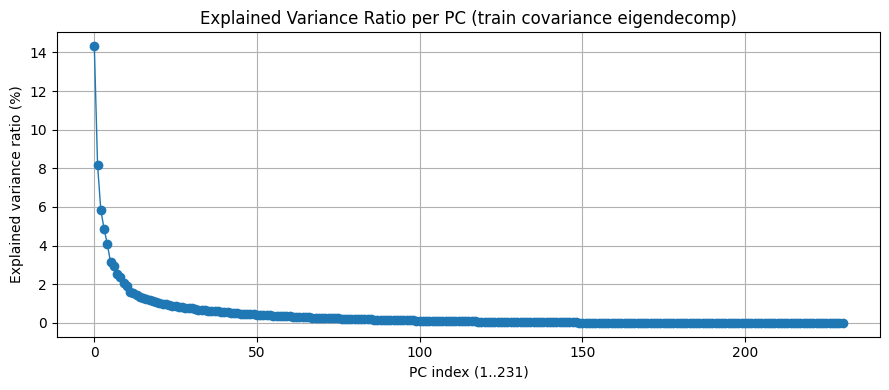

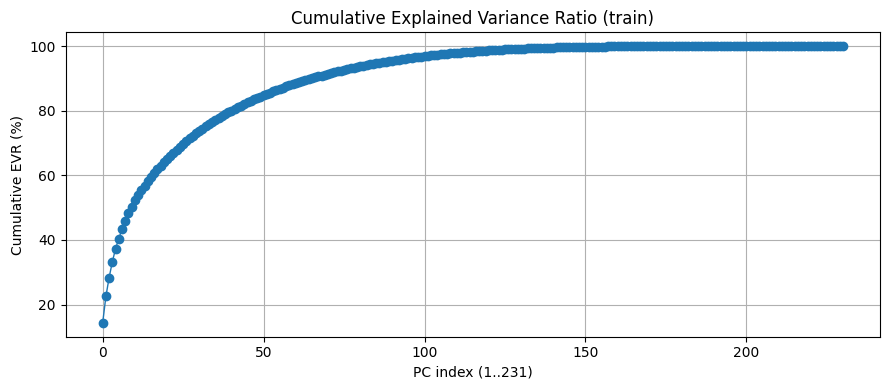

✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/evr_per_pc.png
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/cumulative_evr.png


,pc_index_1based_full,eigenvalue,explained_variance_ratio,explained_variance_ratio_percent,kept_nonzero
0,1,33.276549,0.143231,14.323116,True
1,2,18.993377,0.081753,8.175257,True
2,3,13.545195,0.058302,5.830214,True
3,4,11.331805,0.048775,4.877512,True
4,5,9.454387,0.040694,4.069421,True
5,6,7.286405,0.031363,3.136263,True
6,7,6.841401,0.029447,2.944722,True
7,8,5.894339,0.025371,2.537081,True
8,9,5.489573,0.023629,2.362859,True
9,10,4.832061,0.020798,2.079848,True


In [6]:

# =========================================================
# 4) EVR 그래프 저장 (요청사항)
# =========================================================

plt.figure(figsize=(9,4))
plt.plot(evr * 100.0, marker="o", linewidth=1)
plt.title("Explained Variance Ratio per PC (train covariance eigendecomp)")
plt.xlabel("PC index (1..231)")
plt.ylabel("Explained variance ratio (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(EVR_PNG_PATH, dpi=160)
plt.show()

cum_evr = np.cumsum(evr) * 100.0
plt.figure(figsize=(9,4))
plt.plot(cum_evr, marker="o", linewidth=1)
plt.title("Cumulative Explained Variance Ratio (train)")
plt.xlabel("PC index (1..231)")
plt.ylabel("Cumulative EVR (%)")
plt.grid(True)
plt.tight_layout()
plt.savefig(CUMEVR_PNG_PATH, dpi=160)
plt.show()

print("✅ saved:", EVR_PNG_PATH)
print("✅ saved:", CUMEVR_PNG_PATH)

# 상위 PC들 빠르게 보기
display(ev_df.head(15))


In [7]:

# =========================================================
# 5) 재구성(복원력) 확인: kept 축으로 투영→복원 (train/test)
# =========================================================

def recon_metrics(X_true: np.ndarray, X_hat: np.ndarray) -> dict:
    err = X_true - X_hat
    return {
        "rmse": float(np.sqrt(np.mean(err**2))),
        "mae": float(np.mean(np.abs(err))),
        "max_abs_err": float(np.max(np.abs(err))),
    }

# 복원: X_hat_cs = Z * V^T  -> 역표준화 + 평균 복원
Xtr_hat_cs = Z_train @ V_keep.T
Xte_hat_cs = Z_test  @ V_keep.T

Xtr_hat = Xtr_hat_cs * sigma_safe + mu
Xte_hat = Xte_hat_cs * sigma_safe + mu

m_tr = recon_metrics(Xtr, Xtr_hat)
m_te = recon_metrics(Xte, Xte_hat)

recon_df = pd.DataFrame([{
    "n_train": n_train,
    "n_test": Xte.shape[0],
    "p": p,
    "k_keep": k_keep,
    "standardize_before_pca": STANDARDIZE_BEFORE_PCA,
    "eig_tol": EIG_TOL,
    "train_recon_rmse": m_tr["rmse"],
    "train_recon_mae": m_tr["mae"],
    "train_recon_max_abs_err": m_tr["max_abs_err"],
    "test_recon_rmse": m_te["rmse"],
    "test_recon_mae": m_te["mae"],
    "test_recon_max_abs_err": m_te["max_abs_err"],
}])
recon_df.to_csv(RECON_CSV_PATH, index=False)

print("Train reconstruction RMSE:", m_tr["rmse"])
print("Test  reconstruction RMSE:", m_te["rmse"])
print("✅ saved:", RECON_CSV_PATH)


Train reconstruction RMSE: 1.6404119125200864e-13
Test  reconstruction RMSE: 544.6602640737248
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/reconstruction_check_train_test.csv


In [8]:

# =========================================================
# 6) 관능 1개씩(50번) 반복:
#    - PC 1개(1D)로만 선형회귀 학습
#    - PC별 성능 랭킹
#    - target별 폴더에 전부 저장 + 종합 폴더에 전체 저장
# =========================================================

def safe_name(s: str) -> str:
    # 폴더명에 안전하도록: 한글/영문/숫자/._-만 남기고 나머지는 _
    s = str(s)
    s = re.sub(r"[^0-9A-Za-z가-힣._-]+", "_", s)
    s = s.strip("_")
    return s[:80] if len(s) > 80 else s

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def pearson_corr(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a).ravel()
    b = np.asarray(b).ravel()
    if a.size != b.size or a.size == 0:
        return float("nan")
    if np.std(a) == 0 or np.std(b) == 0:
        return float("nan")
    return float(np.corrcoef(a, b)[0,1])

all_results = []
top_results = []
best1_rows = []

for t_i, target in enumerate(target_cols, start=1):
    target_safe = safe_name(target)
    target_dir = os.path.join(RUN_DIR, f"target_{t_i:02d}_{target_safe}")
    os.makedirs(target_dir, exist_ok=True)

    # target별 파일
    target_all_csv = os.path.join(target_dir, f"single_pc_results_{target_safe}.csv")
    target_top_csv = os.path.join(target_dir, f"top_{TOP_N_PER_TARGET}_pc_{target_safe}.csv")
    target_best_txt= os.path.join(target_dir, f"best_pc_summary_{target_safe}.txt")

    ytr = Y_train[target].values.astype(float)
    yte = Y_test[target].values.astype(float)

    rows = []
    for j in range(k_keep):
        ztr = Z_train[:, [j]]
        zte = Z_test[:,  [j]]

        model = LinearRegression()
        model.fit(ztr, ytr)

        pred_tr = model.predict(ztr)
        pred_te = model.predict(zte)

        train_rmse = rmse(ytr, pred_tr)
        test_rmse  = rmse(yte, pred_te)

        train_r2 = float(r2_score(ytr, pred_tr))
        test_r2  = float(r2_score(yte, pred_te))

        # 요청 "정확도": Pearson correlation로 저장
        train_acc = pearson_corr(ytr, pred_tr)
        test_acc  = pearson_corr(yte, pred_te)

        rows.append({
            "target": target,
            "target_index_1based": t_i,

            "pc_index_1based_kept": j + 1,
            "pc_index_1based_full": int(kept_full_indices[j] + 1),

            "eigenvalue": float(lam_keep[j]),
            "evr": float(evr_keep[j]),
            "evr_percent": float(evr_keep[j] * 100.0),

            "coef": float(model.coef_.ravel()[0]),
            "intercept": float(model.intercept_),

            "train_rmse": train_rmse,
            "train_r2": train_r2,
            "train_accuracy": train_acc,

            "test_rmse": test_rmse,
            "test_r2": test_r2,
            "test_accuracy": test_acc,
        })

    res_df = pd.DataFrame(rows)

    # 성능 랭킹: test_r2 내림차순, 동률이면 test_rmse 오름차순
    res_sorted = res_df.sort_values(["test_r2", "test_rmse"], ascending=[False, True]).reset_index(drop=True)

    # 저장(전체 + topN)
    res_sorted.to_csv(target_all_csv, index=False)
    top_df = res_sorted.head(TOP_N_PER_TARGET).copy()
    top_df.to_csv(target_top_csv, index=False)

    # best 1개 요약 텍스트
    best = res_sorted.iloc[0].to_dict()
    with open(target_best_txt, "w", encoding="utf-8") as f:
        f.write(f"Target: {best['target']} (index {t_i})\n")
        f.write(f"Best PC (full index): {best['pc_index_1based_full']} | (kept index): {best['pc_index_1based_kept']}\n")
        f.write(f"EVR(%): {best['evr_percent']:.6f}\n")
        f.write(f"Train: RMSE={best['train_rmse']:.6f}, R2={best['train_r2']:.6f}, ACC(corr)={best['train_accuracy']:.6f}\n")
        f.write(f"Test : RMSE={best['test_rmse']:.6f}, R2={best['test_r2']:.6f}, ACC(corr)={best['test_accuracy']:.6f}\n")
        f.write(f"Model: y = {best['coef']:.6f} * z + {best['intercept']:.6f}\n")

    # 종합 리스트에 누적
    all_results.append(res_sorted)
    top_results.append(top_df)

    best1_rows.append(best)

    if t_i % 5 == 0:
        print(f"processed targets: {t_i}/{len(target_cols)}")

# ---- 종합 저장 ----
all_df = pd.concat(all_results, axis=0, ignore_index=True)
top_all_df = pd.concat(top_results, axis=0, ignore_index=True)
best1_df = pd.DataFrame(best1_rows)

all_df.to_csv(ALLRES_CSV_PATH, index=False)
top_all_df.to_csv(TOPRES_CSV_PATH, index=False)
best1_df.to_csv(BEST1_CSV_PATH, index=False)

print("✅ saved:", ALLRES_CSV_PATH)
print("✅ saved:", TOPRES_CSV_PATH)
print("✅ saved:", BEST1_CSV_PATH)

# Best PC 빈도(어떤 PC가 여러 target에서 1등인지)
freq = (best1_df["pc_index_1based_full"]
        .value_counts()
        .reset_index())
freq.columns = ["pc_index_1based_full", "count_best1"]
freq.to_csv(PC_FREQ_CSV, index=False)
print("✅ saved:", PC_FREQ_CSV)

display(best1_df.sort_values("test_r2", ascending=False).head(15))


processed targets: 5/50
processed targets: 10/50
processed targets: 15/50
processed targets: 20/50
processed targets: 25/50
processed targets: 30/50
processed targets: 35/50
processed targets: 40/50
processed targets: 45/50
processed targets: 50/50
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/single_pc_results_all_targets.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/top_pc_per_target.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/best_pc_per_target.csv
✅ saved: /home/a202192020/맥주데이터실험/pca/0223/pca_y1_ver2/output/종합/best_pc_frequency.csv


,target,target_index_1based,pc_index_1based_kept,pc_index_1based_full,eigenvalue,evr,evr_percent,coef,intercept,train_rmse,train_r2,train_accuracy,test_rmse,test_r2,test_accuracy
45,alcohol,46,2,2,18.993377,0.081753,8.175257,0.134286,-0.008561,0.496735,0.579860,0.761485,0.505037,0.525667,0.730836
31,bitternes,32,2,2,18.993377,0.081753,8.175257,0.107393,-0.018130,0.537415,0.429915,0.655679,0.571766,0.447382,0.671771
48,co2,49,2,2,18.993377,0.081753,8.175257,0.067331,0.015513,0.523919,0.237745,0.487591,0.458392,0.323162,0.582767
47,body,48,2,2,18.993377,0.081753,8.175257,0.072514,0.004675,0.454611,0.324547,0.569690,0.491536,0.307799,0.555293
13,A_esters_flower,14,28,28,1.935543,0.008331,0.833109,0.027215,-0.031473,0.418217,0.008084,0.089910,0.367300,0.274201,0.525719
42,lactic,43,2,2,18.993377,0.081753,8.175257,-0.072227,-0.019392,0.589391,0.220940,0.470043,0.745404,0.256626,0.551400
14,A_esters_fruity,15,142,142,0.062779,0.000270,0.027022,0.057701,0.016837,0.472662,0.000929,0.030485,0.495018,0.241821,0.503988
46,aftertaste,47,2,2,18.993377,0.081753,8.175257,0.052876,-0.008523,0.557215,0.145340,0.381234,0.589972,0.190835,0.469529
30,acidity,31,2,2,18.993377,0.081753,8.175257,-0.085997,-0.002071,0.752840,0.197701,0.444636,0.808321,0.180157,0.427913
20,F_hops_all,21,2,2,18.993377,0.081753,8.175257,0.085642,0.045753,0.606551,0.273514,0.522985,0.582356,0.179440,0.461064
